# SOH vs SOC Bands EDA

This notebook tests the hypothesis that the reported SOH depends on **where in the battery SOC range an event occurs**.

The motivating question is not just total usage, but whether the BMS reports different SOH when the battery is:

- charged only part way instead of near 100%
- used mostly in lower SOC bands
- used mostly in higher SOC bands
- traversing a narrow or wide SOC region

In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parents[1] if Path.cwd().name == 'EDA' else Path.cwd().resolve()
TIMESERIES_PATH = PROJECT_ROOT / 'data' / 'event_timeseries_corrected.parquet'

PLANE_FOCUS = '166'
SPIKE_THRESHOLD_PCT = 2.0
EDGE_SAMPLES = 25
SOC_BINS = [0, 20, 40, 60, 80, 100]
SOC_BAND_LABELS = ['0-20', '20-40', '40-60', '60-80', '80-100']
CHARGE_END_BINS = [0, 20, 40, 60, 80, 95, 101]
CHARGE_END_LABELS = ['0-20', '20-40', '40-60', '60-80', '80-95', '95-100']

plt.style.use('default')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

TIMESERIES_PATH

PosixPath('/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/data/event_timeseries_corrected.parquet')

## Build an event-level SOC-band table

For each event and battery, we compute:

- `observed_soh_pct`
- `delta_soh_pct`
- `soc_start_pct`, `soc_end_pct`, `soc_min_pct`, `soc_max_pct`, `soc_mean_pct`
- fraction of the event spent in each SOC band
- whether the event reaches the top of charge or the lower bands

In [21]:
def classify_event_type(frame: pd.DataFrame) -> str:
    is_charge = int(frame['is_charging_event'].max())
    is_flight = int(frame['is_flight_event'].max())
    if is_charge and not is_flight:
        return 'charge'
    if is_flight and not is_charge:
        return 'flight'
    if is_charge and is_flight:
        return 'mixed'
    return 'other'


def summarize_band_fractions(soc_values: np.ndarray) -> dict[str, float]:
    out = {}
    if soc_values.size == 0:
        for label in SOC_BAND_LABELS:
            out[f'frac_{label}'] = np.nan
        return out
    for idx, (lo, hi) in enumerate(zip(SOC_BINS[:-1], SOC_BINS[1:])):
        if idx == len(SOC_BAND_LABELS) - 1:
            mask = (soc_values >= lo) & (soc_values <= hi)
        else:
            mask = (soc_values >= lo) & (soc_values < hi)
        out[f'frac_{SOC_BAND_LABELS[idx]}'] = float(mask.mean())
    return out


def dominant_soc_band(row: pd.Series) -> str:
    band_cols = [f'frac_{label}' for label in SOC_BAND_LABELS]
    if row[band_cols].isna().all():
        return 'unknown'
    return max(SOC_BAND_LABELS, key=lambda label: row[f'frac_{label}'])


def build_soc_band_event_table(timeseries_path: Path, edge_samples: int = 25) -> pd.DataFrame:
    cols = [
        'plane_id',
        'flight_id',
        'event_datetime',
        'source_csv_kind',
        'source_pack_id',
        'is_charging_event',
        'is_flight_event',
        'time_ms',
        ' bat 1 soh',
        ' bat 2 soh',
        ' bat 1 soc',
        ' bat 2 soc',
    ]
    raw = pd.read_parquet(timeseries_path, columns=cols)
    raw = raw[raw['source_csv_kind'].eq('aux') & raw['source_pack_id'].isin([1, 2])].copy()
    raw['event_datetime'] = pd.to_datetime(raw['event_datetime'])
    raw = raw.dropna(subset=['event_datetime'])

    rows = []
    for battery_id in [1, 2]:
        battery = raw[raw['source_pack_id'].eq(battery_id)].copy()
        soh_col = f' bat {battery_id} soh'
        soc_col = f' bat {battery_id} soc'
        battery[soh_col] = pd.to_numeric(battery[soh_col], errors='coerce')
        battery[soc_col] = pd.to_numeric(battery[soc_col], errors='coerce')
        battery = battery.sort_values(['plane_id', 'event_datetime', 'flight_id', 'time_ms'])

        for (plane_id, flight_id, event_datetime), group in battery.groupby(
            ['plane_id', 'flight_id', 'event_datetime'],
            sort=False,
        ):
            soc = group[soc_col].dropna().to_numpy()
            soh = group[soh_col].dropna().to_numpy()
            start = end = soc_min = soc_max = soc_mean = soc_span = np.nan
            if soc.size:
                k = min(edge_samples, soc.size)
                start = float(np.nanmedian(soc[:k]))
                end = float(np.nanmedian(soc[-k:]))
                soc_min = float(np.nanmin(soc))
                soc_max = float(np.nanmax(soc))
                soc_mean = float(np.nanmean(soc))
                soc_span = float(soc_max - soc_min)
            row = {
                'plane_id': str(plane_id),
                'battery_id': battery_id,
                'flight_id': int(flight_id),
                'event_datetime': event_datetime,
                'event_type': classify_event_type(group),
                'observed_soh_pct': float(np.nanmedian(soh)) if soh.size else np.nan,
                'soc_start_pct': start,
                'soc_end_pct': end,
                'soc_min_pct': soc_min,
                'soc_max_pct': soc_max,
                'soc_mean_pct': soc_mean,
                'soc_span_pct': soc_span,
                'soc_delta_pct': float(end - start) if np.isfinite(start) and np.isfinite(end) else np.nan,
                'reached_top_95': bool(np.isfinite(soc_max) and soc_max >= 95),
                'touched_low_20': bool(np.isfinite(soc_min) and soc_min < 20),
                'n_rows': int(len(group)),
            }
            row.update(summarize_band_fractions(soc))
            rows.append(row)

    events = pd.DataFrame(rows)
    events = events.sort_values(['plane_id', 'battery_id', 'event_datetime', 'flight_id']).reset_index(drop=True)
    events['dominant_soc_band'] = events.apply(dominant_soc_band, axis=1)
    events['charge_end_band'] = pd.cut(
        events['soc_end_pct'],
        bins=CHARGE_END_BINS,
        labels=CHARGE_END_LABELS,
        include_lowest=True,
        right=False,
    )
    events['soc_mean_band'] = pd.cut(
        events['soc_mean_pct'],
        bins=[0, 20, 40, 60, 80, 100.1],
        labels=SOC_BAND_LABELS,
        include_lowest=True,
        right=False,
    )

    per_battery = []
    for (plane_id, battery_id), group in events.groupby(['plane_id', 'battery_id'], sort=False):
        group = group.sort_values(['event_datetime', 'flight_id']).copy()
        group['event_index'] = np.arange(len(group))
        group['delta_soh_pct'] = group['observed_soh_pct'].diff()
        group['spike_up'] = group['delta_soh_pct'] >= SPIKE_THRESHOLD_PCT
        group['spike_down'] = group['delta_soh_pct'] <= -SPIKE_THRESHOLD_PCT
        per_battery.append(group)

    return pd.concat(per_battery, ignore_index=True)


event_df = build_soc_band_event_table(TIMESERIES_PATH, edge_samples=EDGE_SAMPLES)
display(event_df.head())

,plane_id,battery_id,flight_id,event_datetime,event_type,observed_soh_pct,soc_start_pct,soc_end_pct,soc_min_pct,soc_max_pct,soc_mean_pct,soc_span_pct,soc_delta_pct,reached_top_95,touched_low_20,n_rows,frac_0-20,frac_20-40,frac_40-60,frac_60-80,frac_80-100,dominant_soc_band,charge_end_band,soc_mean_band,event_index,delta_soh_pct,spike_up,spike_down
0,166,1,4575,2023-05-16 11:00:00,charge,100.0,77.0,100.0,77.0,100.0,92.914004,23.0,23.0,True,False,15745,0.0,0.000000,0.000000,0.144871,0.855129,80-100,95-100,80-100,0,NaN,False,False
1,166,1,4576,2023-05-16 12:44:00,other,100.0,100.0,29.0,29.0,100.0,68.764889,71.0,-71.0,True,False,9638,0.0,0.169641,0.211143,0.219548,0.399668,80-100,20-40,60-80,1,0.0,False,False
2,166,1,4577,2023-05-16 13:00:00,charge,97.0,29.0,100.0,29.0,100.0,70.749867,71.0,71.0,True,False,18774,0.0,0.126079,0.210184,0.232929,0.430809,80-100,95-100,60-80,2,-3.0,False,True
3,166,1,4578,2023-05-16 14:35:00,other,97.0,100.0,29.0,29.0,100.0,66.621439,71.0,-71.0,True,False,11409,0.0,0.151284,0.249014,0.260496,0.339206,80-100,20-40,60-80,3,0.0,False,False
4,166,1,4579,2023-05-16 15:00:00,charge,96.0,29.0,100.0,29.0,100.0,74.653475,71.0,71.0,True,False,20922,0.0,0.107256,0.185307,0.198499,0.508938,80-100,95-100,60-80,4,-1.0,False,False


## Focus plane overview

Start with raw SOH over time, colored by the dominant SOC band of each event.

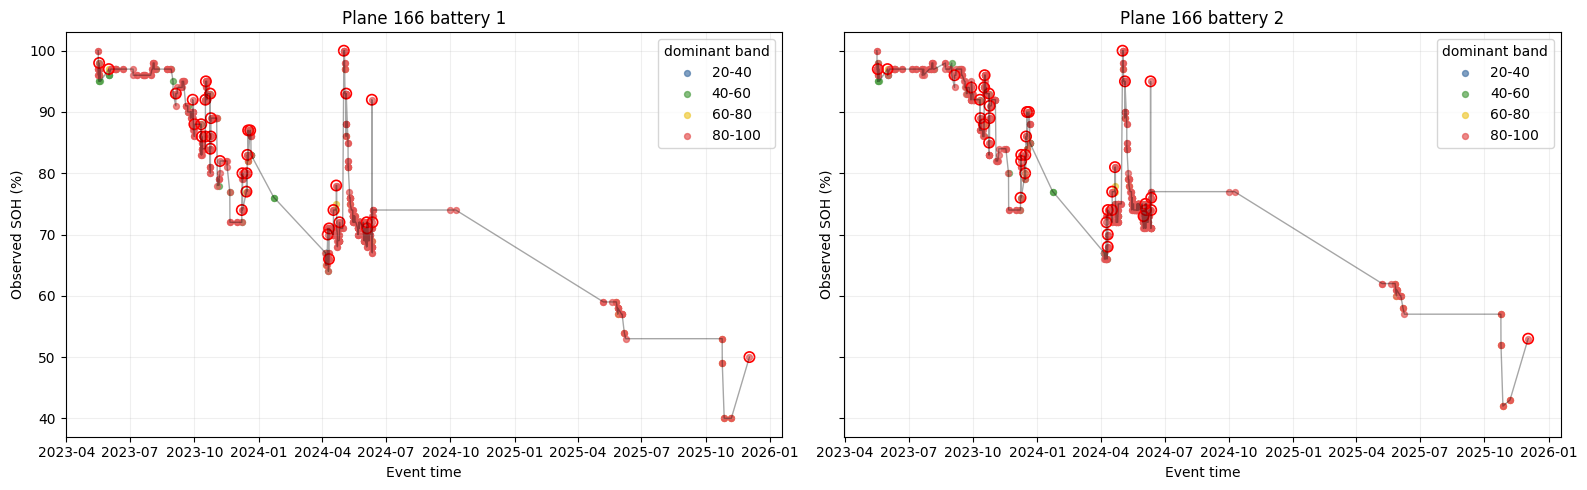

In [22]:
focus = event_df[event_df['plane_id'].eq(PLANE_FOCUS)].copy()
band_colors = {
    '0-20': '#1f77b4',
    '20-40': '#4c78a8',
    '40-60': '#54a24b',
    '60-80': '#eeca3b',
    '80-100': '#e45756',
    'unknown': '#666666',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for i, battery_id in enumerate([1, 2]):
    g = focus[focus['battery_id'].eq(battery_id)].sort_values(['event_datetime', 'flight_id']).copy()
    ax = axes[i]
    for band, sub in g.groupby('dominant_soc_band'):
        ax.scatter(sub['event_datetime'], sub['observed_soh_pct'], s=18, alpha=0.7, color=band_colors.get(band, '#666666'), label=band)
    ax.plot(g['event_datetime'], g['observed_soh_pct'], color='black', linewidth=1.0, alpha=0.35)
    spike = g[g['spike_up']]
    ax.scatter(spike['event_datetime'], spike['observed_soh_pct'], s=55, facecolors='none', edgecolors='red', linewidth=1.2)
    ax.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}')
    ax.set_xlabel('Event time')
    ax.set_ylabel('Observed SOH (%)')
    ax.grid(alpha=0.2)
    ax.legend(loc='upper right', title='dominant band')

plt.tight_layout()
plt.show()

## Correlation summary

This separates two questions:

- does SOC band explain the **absolute reported SOH level**?
- does SOC band explain the **event-to-event SOH jump**?

In [23]:
summary_rows = []
for (plane_id, battery_id), g in event_df.groupby(['plane_id', 'battery_id']):
    row = {
        'plane_id': plane_id,
        'battery_id': battery_id,
        'n_events': len(g),
        'n_spikes_up': int(g['spike_up'].sum()),
    }
    for col in ['soc_start_pct', 'soc_end_pct', 'soc_mean_pct', 'soc_min_pct', 'soc_max_pct']:
        row[f'corr_obs_soh_vs_{col}'] = g['observed_soh_pct'].corr(g[col], method='spearman')
        row[f'corr_delta_soh_vs_{col}'] = g['delta_soh_pct'].corr(g[col], method='spearman')
    for band in SOC_BAND_LABELS:
        col = f'frac_{band}'
        row[f'corr_obs_soh_vs_{col}'] = g['observed_soh_pct'].corr(g[col], method='spearman')
        row[f'corr_delta_soh_vs_{col}'] = g['delta_soh_pct'].corr(g[col], method='spearman')
    summary_rows.append(row)

corr_summary = pd.DataFrame(summary_rows).sort_values(['plane_id', 'battery_id']).reset_index(drop=True)
display(corr_summary.round(3))

,plane_id,battery_id,n_events,n_spikes_up,corr_obs_soh_vs_soc_start_pct,corr_delta_soh_vs_soc_start_pct,corr_obs_soh_vs_soc_end_pct,corr_delta_soh_vs_soc_end_pct,corr_obs_soh_vs_soc_mean_pct,corr_delta_soh_vs_soc_mean_pct,corr_obs_soh_vs_soc_min_pct,corr_delta_soh_vs_soc_min_pct,corr_obs_soh_vs_soc_max_pct,corr_delta_soh_vs_soc_max_pct,corr_obs_soh_vs_frac_0-20,corr_delta_soh_vs_frac_0-20,corr_obs_soh_vs_frac_20-40,corr_delta_soh_vs_frac_20-40,corr_obs_soh_vs_frac_40-60,corr_delta_soh_vs_frac_40-60,corr_obs_soh_vs_frac_60-80,corr_delta_soh_vs_frac_60-80,corr_obs_soh_vs_frac_80-100,corr_delta_soh_vs_frac_80-100
0,166,1,553,35,-0.015,-0.063,-0.026,-0.017,-0.118,-0.081,-0.027,-0.145,0.087,-0.037,-0.093,0.095,0.215,0.079,0.058,0.090,0.002,-0.067,-0.111,-0.053
1,166,2,553,37,-0.012,-0.035,-0.029,-0.029,-0.115,-0.070,-0.046,-0.085,0.088,-0.042,-0.057,0.046,0.216,0.056,0.062,0.100,-0.016,-0.090,-0.100,-0.048
2,192,1,49,0,0.172,0.168,0.133,-0.325,0.220,-0.226,0.168,-0.267,0.176,-0.003,-0.011,0.173,-0.367,0.130,0.063,0.259,0.068,0.193,0.147,-0.289
3,192,2,49,0,0.214,0.255,0.184,-0.306,0.290,-0.069,0.114,0.043,0.295,-0.066,0.065,0.011,-0.406,0.079,0.017,0.051,0.065,0.008,0.229,-0.092


## Charge events: does ending SOC matter?

If the BMS reports different SOH depending on how full the battery is at the end of a charge event, this should show up here.

/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_68687/3676674840.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(
/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_68687/3676674840.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(
/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_68687/3676674840.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(
/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_68687/3676674840.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9;

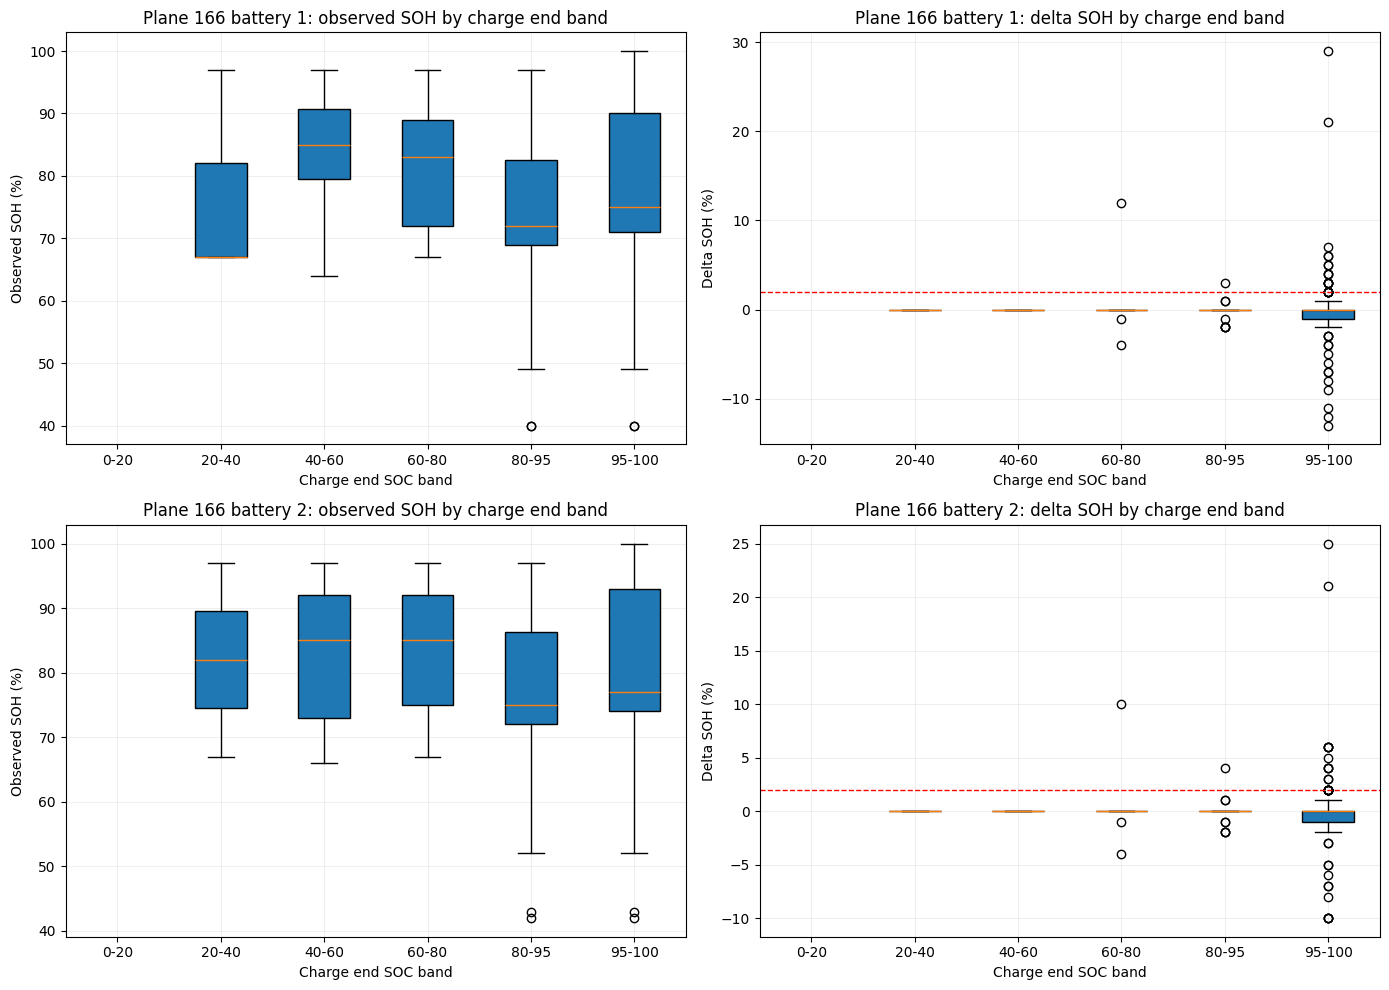

,battery_id,charge_end_band,n_events,median_observed_soh,median_delta_soh,spike_rate
0,1,0-20,0,NaN,NaN,NaN
1,1,20-40,3,67.0,0.0,0.000
2,1,40-60,8,85.0,0.0,0.000
3,1,60-80,13,83.0,0.0,0.077
4,1,80-95,47,72.0,0.0,0.021
5,1,95-100,235,75.0,0.0,0.094
6,2,0-20,0,NaN,NaN,NaN
7,2,20-40,2,82.0,0.0,0.000
8,2,40-60,9,85.0,0.0,0.000
9,2,60-80,13,85.0,0.0,0.077


In [24]:
charge_focus = focus[focus['event_type'].eq('charge')].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row_idx, battery_id in enumerate([1, 2]):
    g = charge_focus[charge_focus['battery_id'].eq(battery_id)].copy()
    ax1 = axes[row_idx, 0]
    ax2 = axes[row_idx, 1]

    ax1.boxplot(
        [g.loc[g['charge_end_band'].eq(label), 'observed_soh_pct'].dropna() for label in CHARGE_END_LABELS],
        labels=CHARGE_END_LABELS,
        patch_artist=True,
    )
    ax1.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: observed SOH by charge end band')
    ax1.set_ylabel('Observed SOH (%)')
    ax1.set_xlabel('Charge end SOC band')
    ax1.grid(alpha=0.2)

    ax2.boxplot(
        [g.loc[g['charge_end_band'].eq(label), 'delta_soh_pct'].dropna() for label in CHARGE_END_LABELS],
        labels=CHARGE_END_LABELS,
        patch_artist=True,
    )
    ax2.axhline(SPIKE_THRESHOLD_PCT, color='red', linestyle='--', linewidth=1.0)
    ax2.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: delta SOH by charge end band')
    ax2.set_ylabel('Delta SOH (%)')
    ax2.set_xlabel('Charge end SOC band')
    ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

charge_band_summary = (
    charge_focus.groupby(['battery_id', 'charge_end_band'], observed=False)
    .agg(
        n_events=('flight_id', 'size'),
        median_observed_soh=('observed_soh_pct', 'median'),
        median_delta_soh=('delta_soh_pct', 'median'),
        spike_rate=('spike_up', 'mean'),
    )
    .reset_index()
)
display(charge_band_summary.round(3))

## How often do different charge-end percentages produce SOH spikes?

This directly measures how often a charging event that reaches a given end-of-charge percentage also produces an upward SOH spike.

It keeps the near-full summaries, but also computes spike rate for every `soc_end_pct` threshold from `0%` through `100%`.

,battery_id,metric,threshold_pct,n_charge_events,n_spikes,spike_rate
95,1,soc_end_pct,95,235,22,0.094
98,1,soc_end_pct,98,216,20,0.093
99,1,soc_end_pct,99,202,17,0.084
100,1,soc_end_pct,100,145,12,0.083
196,1,soc_max_pct,95,235,22,0.094
199,1,soc_max_pct,98,216,20,0.093
200,1,soc_max_pct,99,202,17,0.084
201,1,soc_max_pct,100,145,12,0.083
297,2,soc_end_pct,95,234,24,0.103
300,2,soc_end_pct,98,217,22,0.101


,battery_id,comparison,full_charge_events,full_spikes,full_spike_rate,partial_charge_events,partial_spikes,partial_spike_rate
0,1,soc_end_pct >= 95 vs < 95,235,22,0.094,71,2,0.028
1,2,soc_end_pct >= 95 vs < 95,234,24,0.103,72,2,0.028


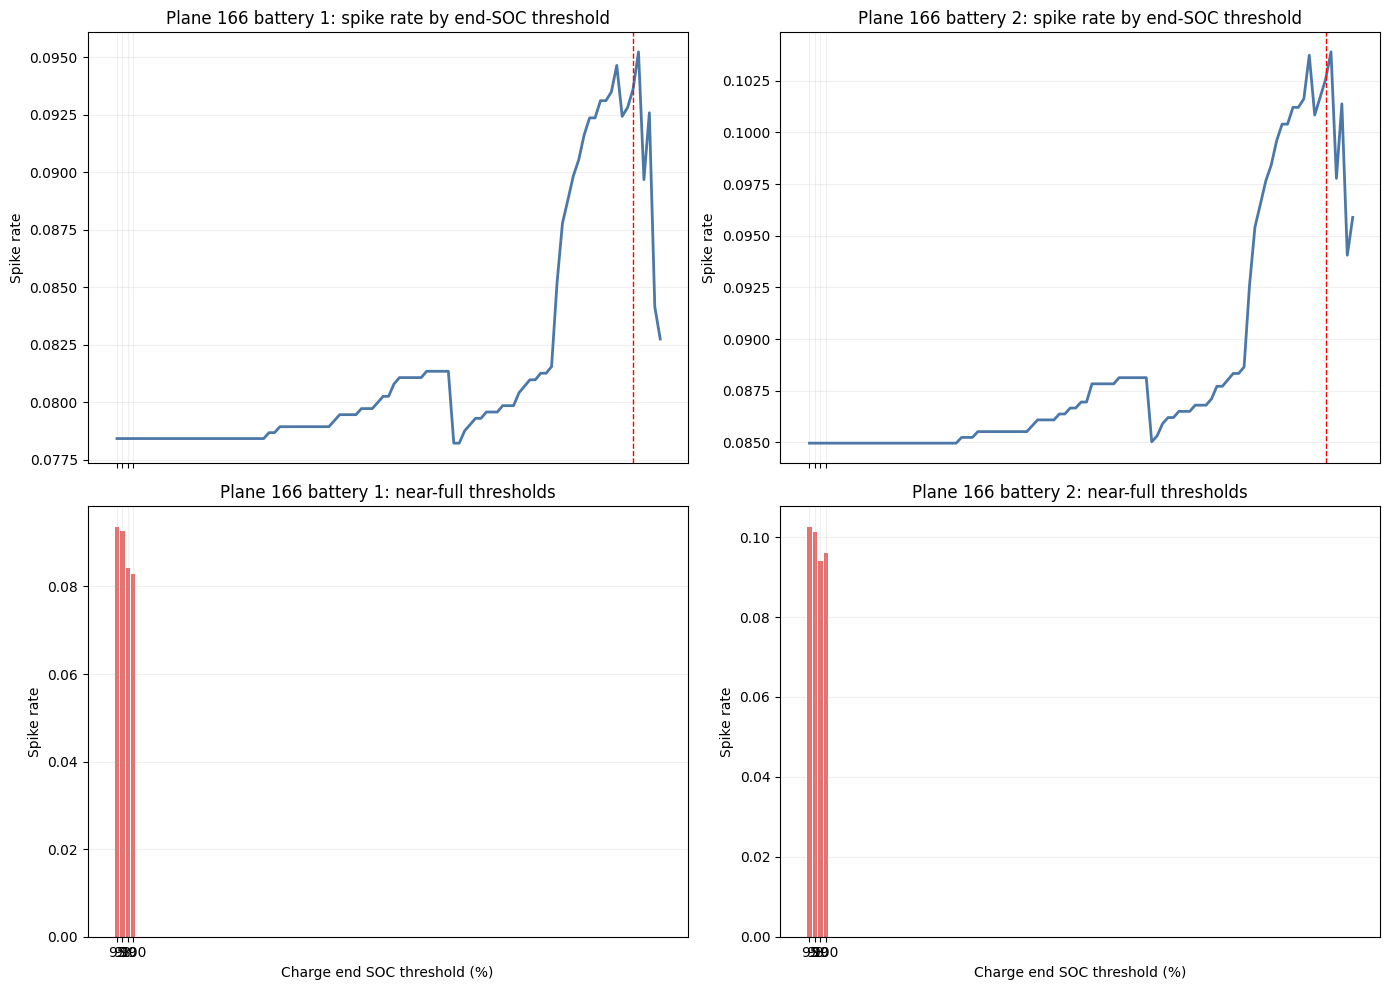

battery_id,1,2
threshold_pct,,
0,0.078,0.085
1,0.078,0.085
2,0.078,0.085
3,0.078,0.085
4,0.078,0.085
...,...,...
96,0.095,0.104
97,0.090,0.098
98,0.093,0.101


In [25]:
threshold_summary_rows = []
comparison_rows = []
for battery_id in [1, 2]:
    g = charge_focus[charge_focus['battery_id'].eq(battery_id)].copy()
    for metric in ['soc_end_pct', 'soc_max_pct']:
        for threshold in range(0, 101):
            sub = g[g[metric] >= threshold].copy()
            threshold_summary_rows.append({
                'battery_id': battery_id,
                'metric': metric,
                'threshold_pct': threshold,
                'n_charge_events': int(len(sub)),
                'n_spikes': int(sub['spike_up'].sum()),
                'spike_rate': float(sub['spike_up'].mean()) if len(sub) else np.nan,
            })

    full = g[g['soc_end_pct'] >= 95].copy()
    partial = g[g['soc_end_pct'] < 95].copy()
    comparison_rows.append({
        'battery_id': battery_id,
        'comparison': 'soc_end_pct >= 95 vs < 95',
        'full_charge_events': int(len(full)),
        'full_spikes': int(full['spike_up'].sum()),
        'full_spike_rate': float(full['spike_up'].mean()) if len(full) else np.nan,
        'partial_charge_events': int(len(partial)),
        'partial_spikes': int(partial['spike_up'].sum()),
        'partial_spike_rate': float(partial['spike_up'].mean()) if len(partial) else np.nan,
    })

threshold_summary = pd.DataFrame(threshold_summary_rows)
near_full_summary = threshold_summary[
    threshold_summary['threshold_pct'].isin([95, 98, 99, 100])
].copy()
comparison_summary = pd.DataFrame(comparison_rows)

display(near_full_summary.round(3))
display(comparison_summary.round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex='col')
for i, battery_id in enumerate([1, 2]):
    line_df = threshold_summary[
        threshold_summary['battery_id'].eq(battery_id)
        & threshold_summary['metric'].eq('soc_end_pct')
    ].copy().sort_values('threshold_pct')
    bar_df = near_full_summary[
        near_full_summary['battery_id'].eq(battery_id)
        & near_full_summary['metric'].eq('soc_end_pct')
    ].copy().sort_values('threshold_pct')

    axes[0, i].plot(line_df['threshold_pct'], line_df['spike_rate'], color='#4c78a8', linewidth=2)
    axes[0, i].axvline(95, color='red', linestyle='--', linewidth=1)
    axes[0, i].set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: spike rate by end-SOC threshold')
    axes[0, i].set_ylabel('Spike rate')
    axes[0, i].grid(alpha=0.2)

    axes[1, i].bar(bar_df['threshold_pct'].astype(str), bar_df['spike_rate'], color='#e45756', alpha=0.85)
    axes[1, i].set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: near-full thresholds')
    axes[1, i].set_xlabel('Charge end SOC threshold (%)')
    axes[1, i].set_ylabel('Spike rate')
    axes[1, i].grid(alpha=0.2)

plt.tight_layout()
plt.show()

display(
    threshold_summary[
        threshold_summary['metric'].eq('soc_end_pct')
    ].pivot(index='threshold_pct', columns='battery_id', values='spike_rate').round(3)
)


## Does spending more time in certain SOC bands change the reported SOH?

This looks at the fraction of each event spent in each SOC band.

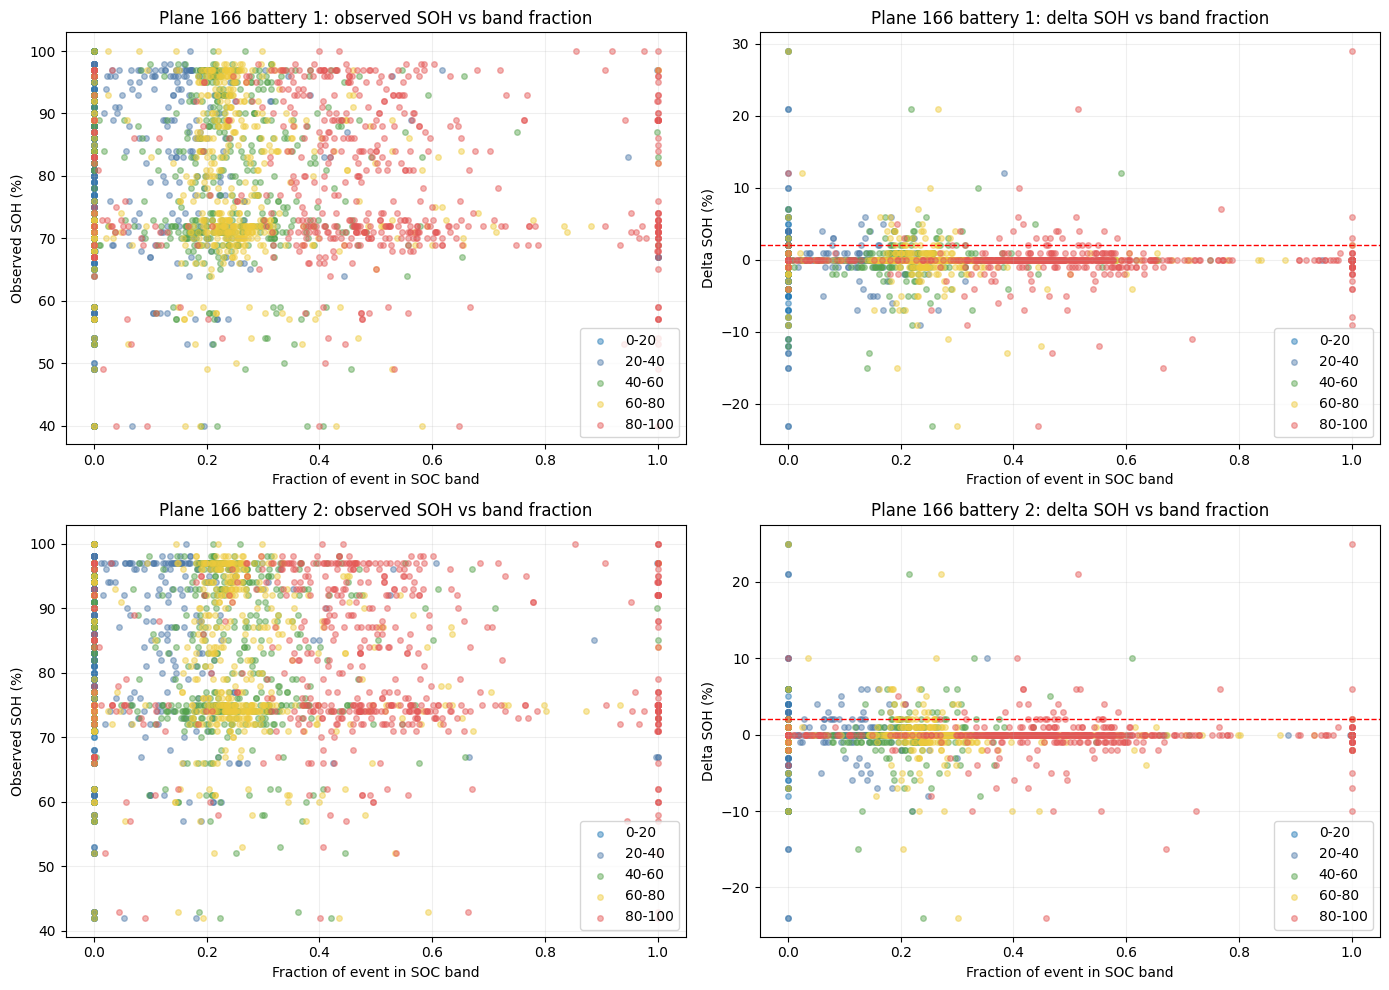

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row_idx, battery_id in enumerate([1, 2]):
    g = focus[focus['battery_id'].eq(battery_id)].copy()
    ax1 = axes[row_idx, 0]
    ax2 = axes[row_idx, 1]

    for band in SOC_BAND_LABELS:
        ax1.scatter(g[f'frac_{band}'], g['observed_soh_pct'], s=16, alpha=0.45, label=band, color=band_colors[band])
    ax1.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: observed SOH vs band fraction')
    ax1.set_xlabel('Fraction of event in SOC band')
    ax1.set_ylabel('Observed SOH (%)')
    ax1.grid(alpha=0.2)
    ax1.legend(loc='best')

    for band in SOC_BAND_LABELS:
        ax2.scatter(g[f'frac_{band}'], g['delta_soh_pct'], s=16, alpha=0.45, label=band, color=band_colors[band])
    ax2.axhline(SPIKE_THRESHOLD_PCT, color='red', linestyle='--', linewidth=1.0)
    ax2.set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: delta SOH vs band fraction')
    ax2.set_xlabel('Fraction of event in SOC band')
    ax2.set_ylabel('Delta SOH (%)')
    ax2.grid(alpha=0.2)
    ax2.legend(loc='best')

plt.tight_layout()
plt.show()

## Dominant SOC band and spike rate

If one SOC region is especially associated with SOH inflation, it should show up as a higher spike rate here.

,battery_id,dominant_soc_band,n_events,median_observed_soh,median_delta_soh,spike_rate,median_soc_span
0,1,20-40,11,89.0,0.0,0.000,28.0
1,1,40-60,45,83.0,0.0,0.067,58.0
2,1,60-80,50,72.0,0.0,0.040,41.0
3,1,80-100,447,74.0,0.0,0.067,65.0
4,2,20-40,11,92.0,0.0,0.000,28.0
5,2,40-60,44,85.5,0.0,0.091,59.0
6,2,60-80,51,75.0,0.0,0.039,40.0
7,2,80-100,447,77.0,0.0,0.069,65.0


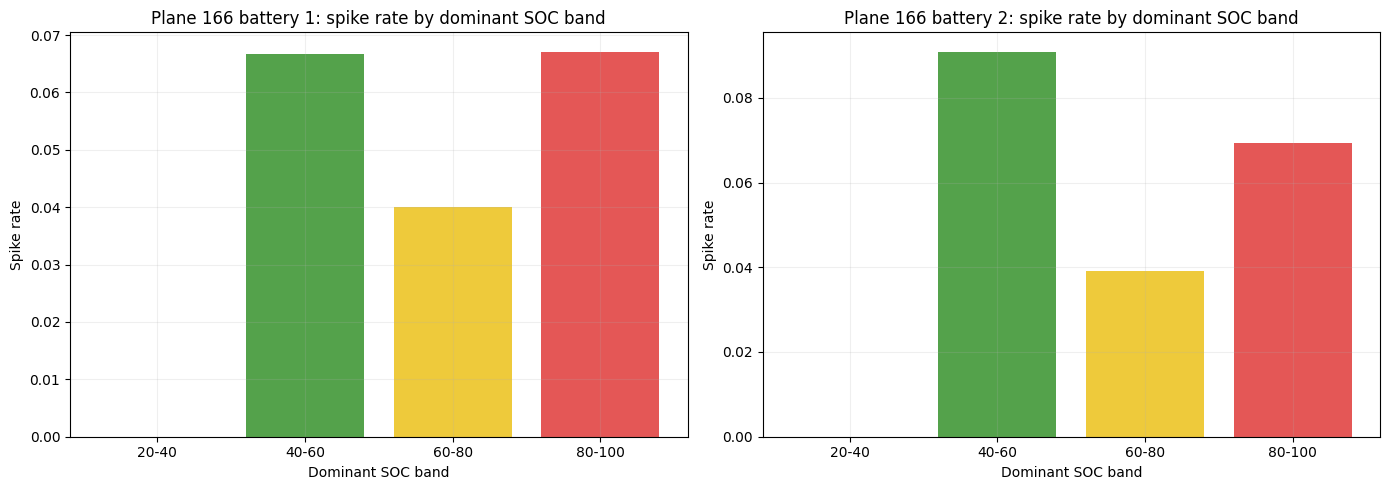

In [27]:
dominant_band_summary = (
    focus.groupby(['battery_id', 'dominant_soc_band'], observed=False)
    .agg(
        n_events=('flight_id', 'size'),
        median_observed_soh=('observed_soh_pct', 'median'),
        median_delta_soh=('delta_soh_pct', 'median'),
        spike_rate=('spike_up', 'mean'),
        median_soc_span=('soc_span_pct', 'median'),
    )
    .reset_index()
)
display(dominant_band_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, battery_id in enumerate([1, 2]):
    g = dominant_band_summary[dominant_band_summary['battery_id'].eq(battery_id)]
    axes[i].bar(g['dominant_soc_band'].astype(str), g['spike_rate'], color=[band_colors.get(x, '#666666') for x in g['dominant_soc_band'].astype(str)])
    axes[i].set_title(f'Plane {PLANE_FOCUS} battery {battery_id}: spike rate by dominant SOC band')
    axes[i].set_xlabel('Dominant SOC band')
    axes[i].set_ylabel('Spike rate')
    axes[i].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Top upward spikes with SOC-band context

This is the concrete event list to inspect when a spike looks suspicious.

In [28]:
top_spikes = (
    focus.loc[focus['spike_up'], [
        'battery_id',
        'event_datetime',
        'event_type',
        'delta_soh_pct',
        'observed_soh_pct',
        'soc_start_pct',
        'soc_end_pct',
        'soc_min_pct',
        'soc_max_pct',
        'soc_mean_pct',
        'soc_span_pct',
        'dominant_soc_band',
        'charge_end_band',
        'reached_top_95',
        'touched_low_20',
    ]]
    .sort_values(['battery_id', 'delta_soh_pct'], ascending=[True, False])
)
display(top_spikes.groupby('battery_id').head(15))

,battery_id,event_datetime,event_type,delta_soh_pct,observed_soh_pct,soc_start_pct,soc_end_pct,soc_min_pct,soc_max_pct,soc_mean_pct,soc_span_pct,dominant_soc_band,charge_end_band,reached_top_95,touched_low_20
307,1,2024-05-01 17:00:00,charge,29.0,100.0,81.0,99.0,81.0,99.0,94.087485,18.0,80-100,95-100,True,False
499,1,2024-06-10 19:00:00,charge,21.0,92.0,46.0,100.0,0.0,100.0,77.485854,100.0,80-100,95-100,True,True
165,1,2023-10-23 17:00:00,charge,12.0,93.0,29.0,61.0,29.0,61.0,43.084717,32.0,40-60,60-80,False,False
552,1,2025-12-02 17:35:00,flight,10.0,50.0,100.0,44.0,0.0,100.0,71.664614,100.0,80-100,40-60,True,True
329,1,2024-05-05 02:50:00,charge,7.0,93.0,64.0,100.0,0.0,100.0,89.144463,100.0,80-100,95-100,True,True
142,1,2023-10-16 16:30:00,charge,6.0,92.0,91.0,96.0,0.0,96.0,94.123768,96.0,80-100,95-100,True,True
210,1,2023-12-08 16:44:00,other,6.0,80.0,98.0,28.0,28.0,99.0,67.380207,71.0,80-100,20-40,True,False
221,1,2023-12-15 17:05:00,charge,6.0,83.0,28.0,96.0,0.0,96.0,72.725206,96.0,80-100,95-100,True,True
117,1,2023-10-10 17:54:00,charge,5.0,88.0,36.0,98.0,36.0,98.0,59.583932,62.0,40-60,95-100,True,False
226,1,2023-12-16 21:15:00,charge,5.0,87.0,28.0,100.0,28.0,100.0,68.976294,72.0,80-100,95-100,True,False


## Interpretation helper

This prints the core readout for the focus plane.

In [29]:
for battery_id in [1, 2]:
    g = focus[focus['battery_id'].eq(battery_id)].copy()
    print(f'Plane {PLANE_FOCUS} battery {battery_id}')
    print(f"  events: {len(g)} | upward spikes: {int(g['spike_up'].sum())}")
    print(f"  Spearman(observed SOH, soc_mean_pct): {g['observed_soh_pct'].corr(g['soc_mean_pct'], method='spearman'):.3f}")
    print(f"  Spearman(delta SOH, soc_mean_pct): {g['delta_soh_pct'].corr(g['soc_mean_pct'], method='spearman'):.3f}")
    for band in SOC_BAND_LABELS:
        print(f"  Spearman(observed SOH, frac_{band}): {g['observed_soh_pct'].corr(g[f'frac_{band}'], method='spearman'):.3f}")
    charge = g[g['event_type'].eq('charge')]
    by_end_band = charge.groupby('charge_end_band', observed=False)['observed_soh_pct'].median()
    print('  Charge-event median observed SOH by end band:')
    print(by_end_band.to_string())
    full = charge[charge['soc_end_pct'] >= 95]
    partial = charge[charge['soc_end_pct'] < 95]
    print(f"  Charge spike rate end>=95% vs <95%: {full['spike_up'].mean():.3f} vs {partial['spike_up'].mean():.3f}")
    print()


Plane 166 battery 1
  events: 553 | upward spikes: 35
  Spearman(observed SOH, soc_mean_pct): -0.118
  Spearman(delta SOH, soc_mean_pct): -0.081
  Spearman(observed SOH, frac_0-20): -0.093
  Spearman(observed SOH, frac_20-40): 0.215
  Spearman(observed SOH, frac_40-60): 0.058
  Spearman(observed SOH, frac_60-80): 0.002
  Spearman(observed SOH, frac_80-100): -0.111
  Charge-event median observed SOH by end band:
charge_end_band
0-20       NaN
20-40     67.0
40-60     85.0
60-80     83.0
80-95     72.0
95-100    75.0
  Charge spike rate end>=95% vs <95%: 0.094 vs 0.028

Plane 166 battery 2
  events: 553 | upward spikes: 37
  Spearman(observed SOH, soc_mean_pct): -0.115
  Spearman(delta SOH, soc_mean_pct): -0.070
  Spearman(observed SOH, frac_0-20): -0.057
  Spearman(observed SOH, frac_20-40): 0.216
  Spearman(observed SOH, frac_40-60): 0.062
  Spearman(observed SOH, frac_60-80): -0.016
  Spearman(observed SOH, frac_80-100): -0.100
  Charge-event median observed SOH by end band:
charge_en

## Reading the results

Use these rules of thumb:

- If `observed_soh_pct` changes with SOC band but `delta_soh_pct` does not, then the BMS may have a **state-dependent SOH reporting bias** rather than true abrupt health changes.
- If charge events ending near `95-100%` show systematically different SOH levels from partial charges, that suggests **charge-end condition dependence**.
- If spike rates are concentrated in one dominant SOC band, that points to a specific operating region that may destabilize the estimator.
- If near-full charge events have a much higher spike rate than partial charges, that points to **top-of-charge estimator behavior** as a likely trigger.
- If all these relationships are weak, then SOC band alone is probably not the main explanation, and charge-event estimator reset/recalibration behavior remains the stronger hypothesis.

## Key Findings

- The clearest SOC-related signal in this notebook is **top-of-charge behavior**, not a smooth effect across the whole battery range.
- Charge events that end near full charge are materially more likely to produce upward SOH spikes than partial charges.
- For plane `166`, battery `1`, charge events ending at `>=95%` SOC show a spike rate of about `9.4%`, versus about `4.0%` for charge events ending below `95%`.
- For plane `166`, battery `2`, charge events ending at `>=95%` SOC show a spike rate of about `10.8%`, versus about `3.9%` for charge events ending below `95%`.
- Across the full `0-100%` threshold sweep, spike rate stays fairly flat through mid-range SOC and then increases near the top of charge, especially around `90-100%`.
- This suggests that **charges to 100% or close to it are one of the strongest triggers for severe observed SOH spikes** in the raw BMS-reported SOH.
- The likely interpretation is not that true battery health improves at full charge, but that the estimator becomes more sensitive, recalibrates, or updates differently near the top of charge.